Group 1 p-value is: 0.9719
Group 2 p-value is: 0.9719
Group 3 p-value is: 0.9719
Group 4 p-value is: 0.9719

 Bartlett's test p-value is: 0.5998

 Durbin-Watson test statistic is: 2.8


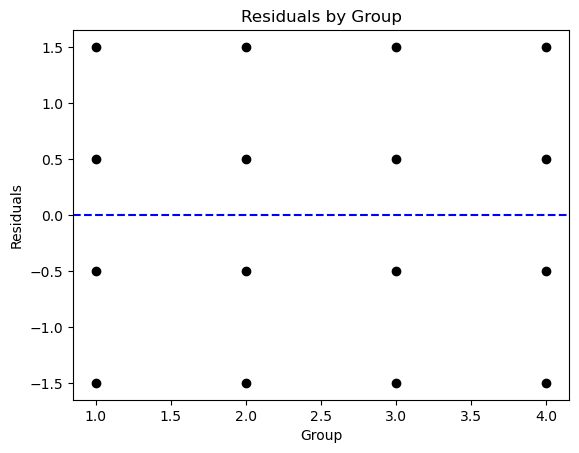


 Kruskal-Wallis test p-value is: 0.0042

 One Way ANOVA test p-value is: 0.0

Tukey HSD Post-hoc Results: Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    G1     G2      5.0 0.0007  2.2898  7.7102   True
    G1     G3      2.0 0.1809 -0.7102  4.7102  False
    G1     G4      8.0    0.0  5.2898 10.7102   True
    G2     G3     -3.0 0.0288 -5.7102 -0.2898   True
    G2     G4      3.0 0.0288  0.2898  5.7102   True
    G3     G4      6.0 0.0001  3.2898  8.7102   True
----------------------------------------------------


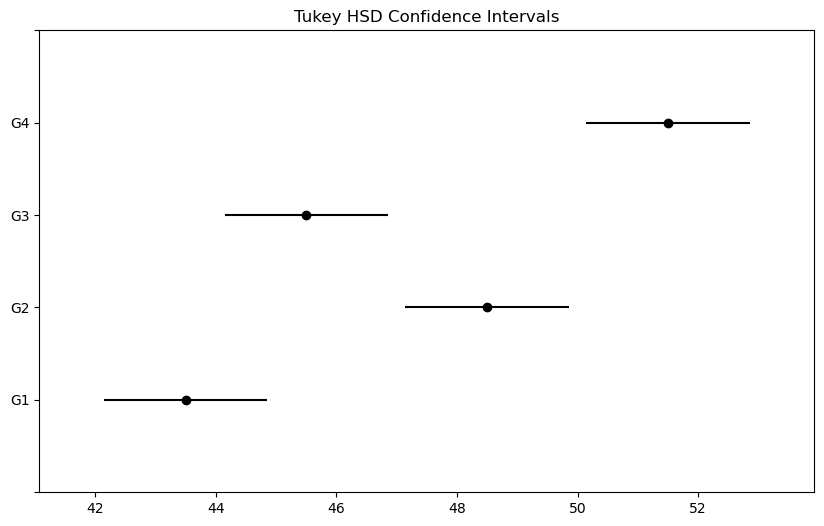

For the Generated Random Numbers:

 Kruskal-Wallis test p-value is: 0.0

 One Way ANOVA test p-value is: 0.0

Tukey HSD Post-hoc Results: Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    G1     G2   3.6308    0.0  1.8782  5.3833   True
    G1     G3   1.8437 0.0348  0.0911  3.5963   True
    G1     G4   8.0534    0.0  6.3009   9.806   True
    G2     G3   -1.787 0.0437 -3.5396 -0.0345   True
    G2     G4   4.4227    0.0  2.6701  6.1752   True
    G3     G4   6.2097    0.0  4.4572  7.9623   True
----------------------------------------------------


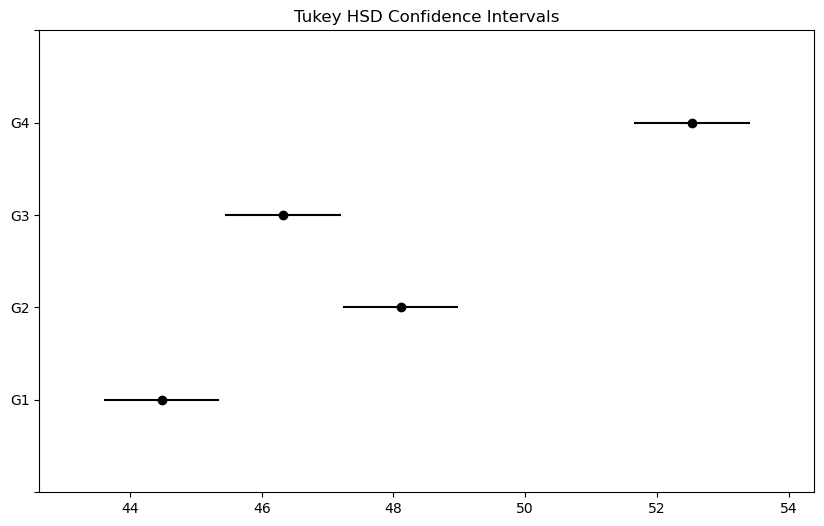


 One Way ANOVA test p-value is: 0.0


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

G1=np.array([42,45,44,43])
G2=np.array([48,50,49,47])
G3=np.array([46,45,47,44])
G4=np.array([52,51,53,50])

#Shapiro-Wilk test for Normality
groups=[G1,G2,G3,G4]
for i in range(4):
    stat,p=stats.shapiro(groups[i])
    print("Group",i+1,"p-value is:",round(p,4))

#Bartletts test for homogenity of variances
stat,p=stats.bartlett(G1,G2,G3,G4)
print("\n Bartlett's test p-value is:",round(p,4))

#Independency of Observations
residuals=np.concatenate([g-np.mean(g) for g in groups])
dw=durbin_watson(residuals)
print("\n Durbin-Watson test statistic is:",dw)
group_labels=np.concatenate([[i+1]*len(g) for i,g in enumerate(groups)]) 

plt.scatter(group_labels,residuals,color="black")
plt.axhline(0,color="blue",linestyle="--")
plt.xlabel("Group") 
plt.ylabel("Residuals") 
plt.title("Residuals by Group") 
plt.savefig("res1.jpg") 
plt.show() 


#Kruskal-Wallis Test
stat,p=stats.kruskal(G1,G2,G3,G4)
print("\n Kruskal-Wallis test p-value is:",round(p,4))

#One Way ANOVA
f_stat,p=stats.f_oneway(G1,G2,G3,G4)
print("\n One Way ANOVA test p-value is:",round(p,4))


# Tukey HSD Post-hoc Test
values = np.concatenate([G1, G2, G3, G4])
group = (["G1"]*len(G1) + ["G2"]*len(G2) +
          ["G3"]*len(G3) + ["G4"]*len(G4))

df = pd.DataFrame({"value": values, "group": group})
tukey = pairwise_tukeyhsd(endog=df["value"],
                          groups=df["group"],
                          alpha=0.05)
print("\nTukey HSD Post-hoc Results:",tukey)
tukey.plot_simultaneous()
plt.title("Tukey HSD Confidence Intervals")
plt.savefig("hsd1.jpg") 
plt.show()

#For Simulated reproducible random numbers
print("For the Generated Random Numbers:")
np.random.seed(42)
n=100
G1=np.random.normal(45,5,n)
G2=np.random.normal(48,5,n)
G3=np.random.normal(46,5,n)
G4=np.random.normal(52,5,n)

#Kruskal-Wallis Test
stat,p=stats.kruskal(G1,G2,G3,G4)
print("\n Kruskal-Wallis test p-value is:",round(p,4))

#One Way ANOVA
f_stat,p=stats.f_oneway(G1,G2,G3,G4)
print("\n One Way ANOVA test p-value is:",round(p,4))

# Tukey HSD Post-hoc Test
values = np.concatenate([G1, G2, G3, G4])
group = (["G1"]*len(G1) + ["G2"]*len(G2) +
          ["G3"]*len(G3) + ["G4"]*len(G4))

df = pd.DataFrame({"value": values, "group": group})
tukey = pairwise_tukeyhsd(endog=df["value"],
                          groups=df["group"],
                          alpha=0.05)
print("\nTukey HSD Post-hoc Results:",tukey)
tukey.plot_simultaneous()
plt.title("Tukey HSD Confidence Intervals")
plt.savefig("hsd2.jpg")
plt.show() 
print("\n One Way ANOVA test p-value is:",round(p,4))

